# F1 CONSTRUCTOR POINTS

## Análisis Descriptivo

Este proyecto tiene como objetivo desarrollar un dashboard interactivo que permita analizar los puntos promedio obtenidos por cada constructor en cada temporada de Fórmula 1 desde el año 2010 en adelante.

In [2]:
import pandas as pd

In [63]:
constructor_results = pd.read_csv('data/constructor_results.csv')
constructors = pd.read_csv('data/constructors.csv')
races = pd.read_csv('data/races.csv')

In [64]:
constructor_results.head()

,constructorResultsId,raceId,constructorId,points,status
0,1,18,1,14.0,\N
1,2,18,2,8.0,\N
2,3,18,3,9.0,\N
3,4,18,4,5.0,\N
4,5,18,5,2.0,\N


In [65]:
constructor_results.dtypes

constructorResultsId      int64
raceId                    int64
constructorId             int64
points                  float64
status                   object
dtype: object

In [66]:
constructors.head()

,constructorId,constructorRef,name,nationality,url
0,1,mclaren,McLaren,British,http://en.wikipedia.org/wiki/McLaren
1,2,bmw_sauber,BMW Sauber,German,http://en.wikipedia.org/wiki/BMW_Sauber
2,3,williams,Williams,British,http://en.wikipedia.org/wiki/Williams_Grand_Pr...
3,4,renault,Renault,French,http://en.wikipedia.org/wiki/Renault_in_Formul...
4,5,toro_rosso,Toro Rosso,Italian,http://en.wikipedia.org/wiki/Scuderia_Toro_Rosso


In [67]:
races.head()

,raceId,year,round,circuitId,name,date,time,url
0,1,2009,1,1,Australian Grand Prix,29/03/09,6:00:00,http://en.wikipedia.org/wiki/2009_Australian_G...
1,2,2009,2,2,Malaysian Grand Prix,05/04/09,9:00:00,http://en.wikipedia.org/wiki/2009_Malaysian_Gr...
2,3,2009,3,17,Chinese Grand Prix,19/04/09,7:00:00,http://en.wikipedia.org/wiki/2009_Chinese_Gran...
3,4,2009,4,3,Bahrain Grand Prix,26/04/09,12:00:00,http://en.wikipedia.org/wiki/2009_Bahrain_Gran...
4,5,2009,5,4,Spanish Grand Prix,10/05/09,12:00:00,http://en.wikipedia.org/wiki/2009_Spanish_Gran...


In [68]:
races.dtypes

raceId        int64
year          int64
round         int64
circuitId     int64
name         object
date         object
time         object
url          object
dtype: object

In [69]:
constructor_results = constructor_results.merge(constructors[['constructorId', 'name']], on='constructorId', how='left')
constructor_results.head()

,constructorResultsId,raceId,constructorId,points,status,name
0,1,18,1,14.0,\N,McLaren
1,2,18,2,8.0,\N,BMW Sauber
2,3,18,3,9.0,\N,Williams
3,4,18,4,5.0,\N,Renault
4,5,18,5,2.0,\N,Toro Rosso


In [70]:
constructor_results = constructor_results.merge(races[['raceId', 'year']], on='raceId', how='left')
constructor_results.head()

,constructorResultsId,raceId,constructorId,points,status,name,year
0,1,18,1,14.0,\N,McLaren,2008
1,2,18,2,8.0,\N,BMW Sauber,2008
2,3,18,3,9.0,\N,Williams,2008
3,4,18,4,5.0,\N,Renault,2008
4,5,18,5,2.0,\N,Toro Rosso,2008


In [71]:
constructor_results = constructor_results[(constructor_results['year'] >= 2010) & (constructor_results['year'] <= 2021)]
constructor_results.head()


,constructorResultsId,raceId,constructorId,points,status,name,year
9403,13900,337,6,43.0,\N,Ferrari,2010
9404,13901,337,1,21.0,\N,McLaren,2010
9405,13902,337,9,16.0,\N,Red Bull,2010
9406,13903,337,131,18.0,\N,Mercedes,2010
9407,13904,337,10,2.0,\N,Force India,2010


In [72]:
constructor_results.to_csv('data/results/results_intermediate.csv', index=False)

In [3]:
df = pd.read_csv('data/results/results_intermediate.csv')

Sumar todos los puntos de un mismo constructor en cada temporada y sacar la media y la desviación típica

In [ ]:
df = df.drop(columns=['constructorId', 'status', 'raceId', 'constructorResultsId'])
df = df.reset_index(drop=True)
df.head()

,points,name,year
0,43.0,Ferrari,2010
1,21.0,McLaren,2010
2,16.0,Red Bull,2010
3,18.0,Mercedes,2010
4,2.0,Force India,2010


In [75]:
df = df.rename(columns={'name': 'constructor', 'year': 'season'})
df.head()

,points,constructor,season
0,43.0,Ferrari,2010
1,21.0,McLaren,2010
2,16.0,Red Bull,2010
3,18.0,Mercedes,2010
4,2.0,Force India,2010


In [76]:
# Group the dataframe to compute mean and std of points for each constructor and season
df_stats = df.groupby(["constructor", "season"]).points.agg(["mean", "std"]).reset_index()

# Rename the columns as requested
df_stats = df_stats.rename(columns={'constructor': 'Constructor', 'season': 'Season', 'mean': 'Mean', 'std': 'Std'})

# Round mean and std to 4 decimal places
df_stats["Mean"] = df_stats["Mean"].round(4)
df_stats["Std"] = df_stats["Std"].round(4)

# Display the result
df_stats.head()

,Constructor,Season,Mean,Std
0,Alfa Romeo,2019,2.7143,4.9411
1,Alfa Romeo,2020,0.4706,0.9432
2,Alfa Romeo,2021,0.5909,1.2212
3,AlphaTauri,2020,6.2941,6.3518
4,AlphaTauri,2021,6.4545,6.8642


### Explicación del código anterior:

- `df.groupby(["constructor", "season"])`: Agrupa el DataFrame `df` por las columnas `"constructor"` y `"season"`. Esto significa que todas las filas con el mismo constructor y temporada se agrupan juntas.  
- `.points.agg(["mean", "std"])`: Para cada grupo, se calculan dos estadísticas sobre la columna `"points"`:  
  - `"mean"`: La media (promedio) de los puntos obtenidos por el constructor en esa temporada.  
  - `"std"`: La desviación estándar de los puntos obtenidos por el constructor en esa temporada, que mide la variabilidad de los puntos.  
- `.reset_index()`: Convierte los datos agrupados en un DataFrame regular, restableciendo el índice. Las columnas agrupadas (`"constructor"` y `"season"`) se convierten en columnas normales en el DataFrame resultante.  

El DataFrame resultante (`df_stats`) tendrá la siguiente estructura:

| Constructor | Season | Mean | Std |
|-------------|--------|------|-----|
| Nombre del constructor | Año | Media de los puntos | Desviación estándar de los puntos |

In [77]:
df_stats.columns = ['team', 'year', 'mean', 'std']
df_stats.to_csv('data/results/final_results.csv', index=False)

In [79]:
max_row = df_stats.loc[df_stats['mean'].idxmax()]
print(max_row)

team    Mercedes
year        2015
mean        37.0
std      10.5515
Name: 69, dtype: object


## Análisis Predictivo

Implementar:
1. Un método paramétrico
2. Un método no paramétrico

Asociado a un problema de regresión asociado al conjunto de datos.

In [39]:
df_stats = pd.read_csv('data/results/final_results.csv')
df_stats.shape

(130, 4)

Demasiados pocos datos!

In [41]:
df = pd.read_csv('data/results/results_intermediate.csv')
df = df.drop(columns=['constructorId', 'status', 'constructorResultsId'])
df = df.reset_index(drop=True)
df.to_csv('data/results/final_results_4_prediction.csv', index=False)
df.head()

,raceId,points,name,year
0,337,43.0,Ferrari,2010
1,337,21.0,McLaren,2010
2,337,16.0,Red Bull,2010
3,337,18.0,Mercedes,2010
4,337,2.0,Force India,2010


In [22]:
df.shape

(2542, 4)

##### Intento 1 (Mal)

In [23]:
# DataFrame con todos los puntos de Ferrari entre 2010 y 2020
ferrari_train = df[(df['name'] == 'Ferrari') & (df['year'] >= 2010) & (df['year'] <= 2020)]

# DataFrame con los puntos de Ferrari del año 2021
ferrari_test = df[(df['name'] == 'Ferrari') & (df['year'] == 2021)]

In [24]:
ferrari_train.shape, ferrari_test.shape

((215, 4), (22, 4))

In [25]:
ferrari_train.head()

,raceId,points,name,year
0,337,43.0,Ferrari,2010
14,338,27.0,Ferrari,2010
29,339,6.0,Ferrari,2010
38,340,14.0,Ferrari,2010
49,341,26.0,Ferrari,2010


In [26]:
ferrari_train.tail()

,raceId,points,name,year
2275,1043,10.0,Ferrari,2020
2284,1044,27.0,Ferrari,2020
2297,1045,1.0,Ferrari,2020
2308,1046,0.0,Ferrari,2020
2319,1047,0.0,Ferrari,2020


In [27]:
ferrari_test.head()

,raceId,points,name,year
2325,1052,12.0,Ferrari,2021
2335,1053,22.0,Ferrari,2021
2345,1054,8.0,Ferrari,2021
2354,1055,18.0,Ferrari,2021
2362,1056,18.0,Ferrari,2021


In [28]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Prepare training data from ferrari_train
X_train = ferrari_train[['raceId']]
y_train = ferrari_train['points']

# Create and train the linear regression model
model = LinearRegression()
model.fit(X_train, y_train)

# Prepare test data from ferrari_test and predict points for each race
X_test = ferrari_test[['raceId']]
predictions = model.predict(X_test)

# Add the predictions as a new column in ferrari_test and display
ferrari_test = ferrari_test.copy()
ferrari_test['predicted_points'] = predictions

# Calculate error metrics between predicted and real points
mae = mean_absolute_error(ferrari_test['points'], ferrari_test['predicted_points'])
mse = mean_squared_error(ferrari_test['points'], ferrari_test['predicted_points'])

print(f"Mean Absolute Error: {mae}")
print(f"Mean Squared Error: {mse}")

print(ferrari_test[['raceId', 'points', 'predicted_points']])

Mean Absolute Error: 5.924139254595745
Mean Squared Error: 60.28856124606645
      raceId  points  predicted_points
2325    1052    12.0         19.871363
2335    1053    22.0         19.870704
2345    1054     8.0         19.870045
2354    1055    18.0         19.869386
2362    1056    18.0         19.868726
2375    1057    16.0         19.868067
2388    1059     0.0         19.866749
2395    1058    14.0         19.867408
2405    1060    14.0         19.866090
2413    1061    26.0         19.865430
2425    1062    15.0         19.864771
2439    1063     2.5         19.864112
2445    1064    16.0         19.863453
2454    1065    20.0         19.862793
2464    1066    15.0         19.862134
2474    1067    16.0         19.861475
2484    1069    18.0         19.860157
2495    1070    18.0         19.859497
2504    1071    19.0         19.858838
2516    1051    10.0         19.872023
2527    1072    10.0         19.858179
2534    1073    16.0         19.857520


In [29]:
from sklearn.ensemble import RandomForestRegressor

# Initialize the Random Forest Regressor with a fixed random state for reproducibility
model_rf = RandomForestRegressor(random_state=73)
model_rf.fit(X_train, y_train)

# Predict points for the test races
rf_predictions = model_rf.predict(X_test)

# Create a copy of ferrari_test and add the RF predictions as a new column
ferrari_test_rf = ferrari_test.copy()
ferrari_test_rf['predicted_points_rf'] = rf_predictions

# Calculate error metrics for the Random Forest model
mae_rf = mean_absolute_error(ferrari_test_rf['points'], ferrari_test_rf['predicted_points_rf'])
mse_rf = mean_squared_error(ferrari_test_rf['points'], ferrari_test_rf['predicted_points_rf'])

print(f"Random Forest Mean Absolute Error: {mae_rf}")
print(f"Random Forest Mean Squared Error: {mse_rf}")
print(ferrari_test_rf[['raceId', 'points', 'predicted_points_rf']])

Random Forest Mean Absolute Error: 14.268181818181814
Random Forest Mean Squared Error: 235.9890363636363
      raceId  points  predicted_points_rf
2325    1052    12.0                 0.48
2335    1053    22.0                 0.48
2345    1054     8.0                 0.48
2354    1055    18.0                 0.48
2362    1056    18.0                 0.48
2375    1057    16.0                 0.48
2388    1059     0.0                 0.48
2395    1058    14.0                 0.48
2405    1060    14.0                 0.48
2413    1061    26.0                 0.48
2425    1062    15.0                 0.48
2439    1063     2.5                 0.48
2445    1064    16.0                 0.48
2454    1065    20.0                 0.48
2464    1066    15.0                 0.48
2474    1067    16.0                 0.48
2484    1069    18.0                 0.48
2495    1070    18.0                 0.48
2504    1071    19.0                 0.48
2516    1051    10.0                 0.48
2527    1072

##### Intento 2

🔹 Regresión Lineal
MSE: 138.52529551978188
R²: -0.013597080141812823

🔹 Random Forest Regressor
MSE: 54.5450930050802
R²: 0.6008906041415536


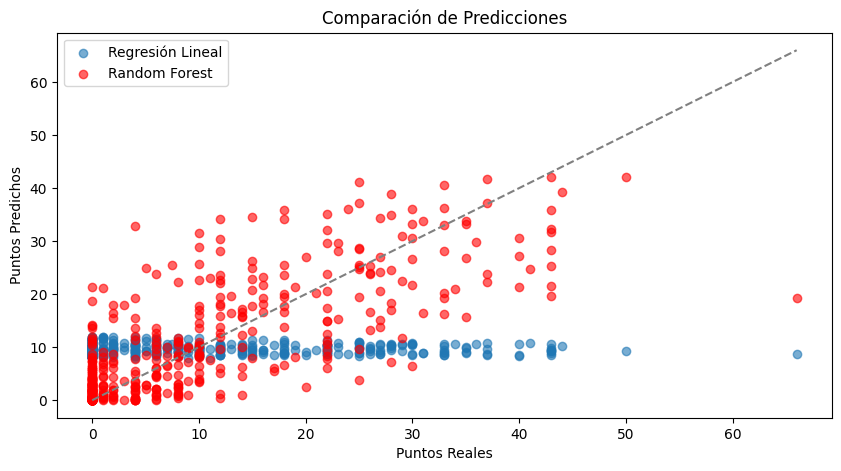

In [42]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# 🔹 Cargar el dataset
df_stats = pd.read_csv('data/results/final_results_4_prediction.csv')

# 🔹 Preprocesamiento
# Codificar la variable categórica 'name' (equipo)
le = LabelEncoder()
df["name_encoded"] = le.fit_transform(df["name"])

# Seleccionar variables predictoras y variable objetivo
X = df[["raceId", "year", "name_encoded"]]
y = df["points"]

# 🔹 Dividir en conjunto de entrenamiento y prueba (80%-20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 🔹 Normalizar los datos (opcional pero recomendado para regresión lineal)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 🔹 Entrenar Regresión Lineal
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)
y_pred_lr = lr.predict(X_test_scaled)

# 🔹 Entrenar Random Forest
rf = RandomForestRegressor(n_estimators=300, max_depth=20, random_state=42)
rf.fit(X_train, y_train)  # Nota: Random Forest no necesita escalado
y_pred_rf = rf.predict(X_test)

# 🔹 Evaluar los modelos
print("🔹 Regresión Lineal")
print("MSE:", mean_squared_error(y_test, y_pred_lr))
print("R²:", r2_score(y_test, y_pred_lr))

print("\n🔹 Random Forest Regressor")
print("MSE:", mean_squared_error(y_test, y_pred_rf))
print("R²:", r2_score(y_test, y_pred_rf))

# 🔹 Visualizar Predicciones
plt.figure(figsize=(10,5))
plt.scatter(y_test, y_pred_lr, label="Regresión Lineal", alpha=0.6)
plt.scatter(y_test, y_pred_rf, label="Random Forest", alpha=0.6, color="red")
plt.plot([0, max(y_test)], [0, max(y_test)], linestyle="--", color="gray")  # Línea y=x
plt.xlabel("Puntos Reales")
plt.ylabel("Puntos Predichos")
plt.legend()
plt.title("Comparación de Predicciones")
plt.show()




##### Intento 3

In [98]:
ferrari = df[df['name'] == 'Ferrari']
ferrari = ferrari.drop(columns=['name', 'year', 'name_encoded', 'raceId']).reset_index(drop=True)
ferrari.head(), ferrari.shape

(   points
 0   43.00
 1   27.00
 2    6.00
 3   14.00
 4   26.00,
 (237, 1))

In [108]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Crear las variables de retraso (lags)
def create_lag_features(df, lag=6):
    for i in range(1, lag + 1):
        df[f'lag_{i}'] = df['points'].shift(i)
    return df

data = create_lag_features(ferrari)
data.dropna(inplace=True)  # Eliminar filas con valores NaN

# Separar en features (X) y target (y)
X = data[[f'lag_{i}' for i in range(1, 7)]]
y = data['points']

# Dividir en conjunto de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, shuffle=False)

# Crear y entrenar el modelo
model = LinearRegression()
model.fit(X_train, y_train)

# Hacer predicciones
y_pred = model.predict(X_test)

# Evaluar el modelo
mae = mean_absolute_error(y_test, y_pred)
print(f'Error absoluto medio (MSE): {mae}')
# Calculate and print R^2 score
r2 = model.score(X_test, y_test)
print(f'R^2 Score: {r2}')

Error absoluto medio (MSE): 6.906140530810373
R^2 Score: -0.4871507375615034


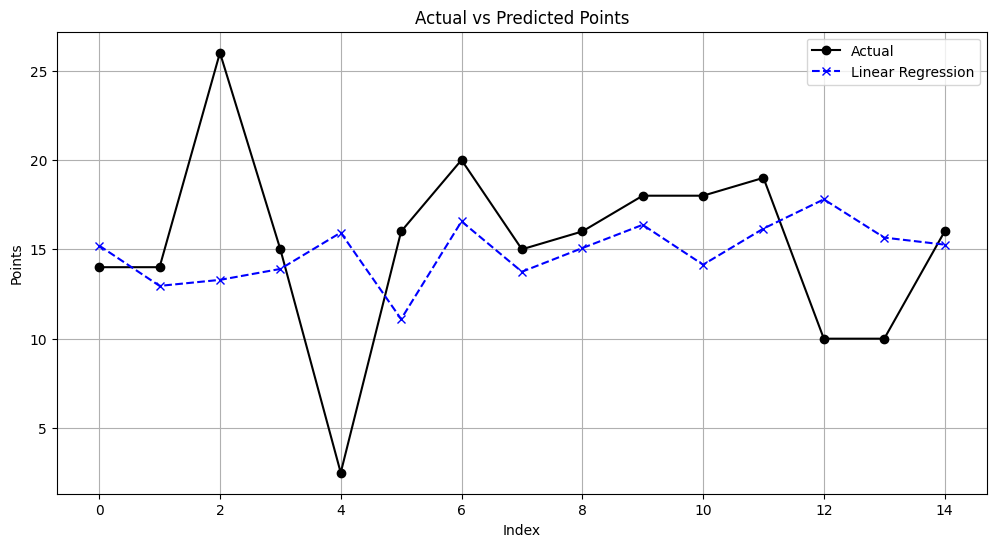

In [97]:
import matplotlib.pyplot as plt

# Plot the actual vs predicted values
plt.figure(figsize=(12, 6))
plt.plot(y_test.values, label='Actual', marker='o', linestyle='-', color='black')
plt.plot(y_pred, label='Linear Regression', marker='x', linestyle='--', color='blue')

# Add labels, legend, and title
plt.xlabel('Index')
plt.ylabel('Points')
plt.title('Actual vs Predicted Points')
plt.legend()
plt.grid(True)
plt.show()

In [109]:
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Crear las variables de retraso (lags)
def create_lag_features(df, lag=12):
    for i in range(1, lag + 1):
        df[f'lag_{i}'] = df['points'].shift(i)
    return df

# Crear las características de retraso
data = create_lag_features(ferrari)
data.dropna(inplace=True)  # Eliminar filas con valores NaN

# Separar en features (X) y target (y)
X = data[[f'lag_{i}' for i in range(1, 7)]]
y = data['points']

# Dividir en conjunto de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, shuffle=False)

# Crear y entrenar el modelo Random Forest
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Hacer predicciones
y_pred = model.predict(X_test)

# Evaluar el modelo
mae = mean_absolute_error(y_test, y_pred)
print(f'Error absoluto medio (MAE): {mae}')
# Calculate and print R^2 score
r2 = model.score(X_test, y_test)
print(f'R^2 Score: {r2}')

Error absoluto medio (MAE): 7.503030303030303
R^2 Score: -0.4814699916743901


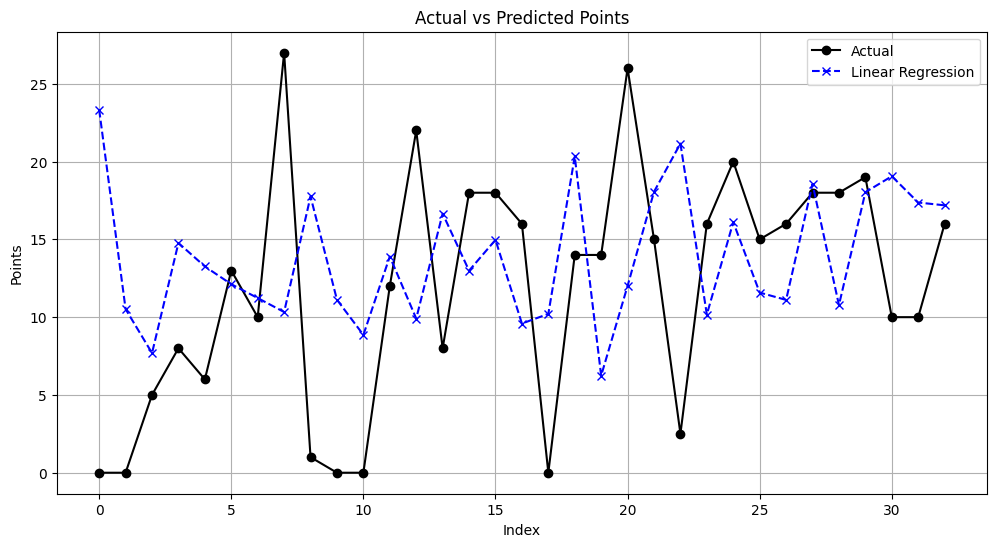

In [110]:
import matplotlib.pyplot as plt

# Plot the actual vs predicted values
plt.figure(figsize=(12, 6))
plt.plot(y_test.values, label='Actual', marker='o', linestyle='-', color='black')
plt.plot(y_pred, label='Linear Regression', marker='x', linestyle='--', color='blue')

# Add labels, legend, and title
plt.xlabel('Index')
plt.ylabel('Points')
plt.title('Actual vs Predicted Points')
plt.legend()
plt.grid(True)
plt.show()

El R^2 DE -0.48 indica que lo hecho anteriormente es una jodida **basura, porquería, desperdicio, desecho, inmundicia, chatarra, mugre, suciedad, detrito, escoria, excrecencia, detritus, escombro, ripio, ruina, suciedad, estropicio, chafaldrana, piltrafa, mondongo, bazofia, muladar, abyección, ignominia, miseria, deyección, ripioso, sabandija, putrefacción, bodrio, bosta, cagarruta, rezago, sobras, lastre, chusma, harapos, guarrería, trasto, residuos, triquiñuela, cutrez, ordinariez, patraña, menjunje, insulso, irrelevante, anodino, chingadera y mierdero**.

#### Y SI HAGO REGRESIÓN A LAS LAP TIMES PARA VER SI PREDECIMOS LA EVOLUCIÓN DE LA VELOCIDAD DEL COCHE??????

In [124]:
df = pd.read_csv('data/lap_times.csv')
df.head()

,raceId,driverId,lap,position,time,milliseconds
0,841,20,1,1,1:38.109,98109
1,841,20,2,1,1:33.006,93006
2,841,20,3,1,1:32.713,92713
3,841,20,4,1,1:32.803,92803
4,841,20,5,1,1:32.342,92342


In [125]:
df.shape

(517573, 6)

In [126]:
races = pd.read_csv('data/races.csv')
df = df.merge(races[['raceId', 'year', 'name']], on='raceId', how='left')
df.head()

,raceId,driverId,lap,position,time,milliseconds,year,name
0,841,20,1,1,1:38.109,98109,2011,Australian Grand Prix
1,841,20,2,1,1:33.006,93006,2011,Australian Grand Prix
2,841,20,3,1,1:32.713,92713,2011,Australian Grand Prix
3,841,20,4,1,1:32.803,92803,2011,Australian Grand Prix
4,841,20,5,1,1:32.342,92342,2011,Australian Grand Prix


In [127]:
# Order the dataframe by raceId and year
df = df.sort_values(by=['raceId', 'year']).reset_index(drop=True)
df.head()

,raceId,driverId,lap,position,time,milliseconds,year,name
0,1,1,1,13,1:49.088,109088,2009,Australian Grand Prix
1,1,1,2,12,1:33.740,93740,2009,Australian Grand Prix
2,1,1,3,11,1:31.600,91600,2009,Australian Grand Prix
3,1,1,4,10,1:31.067,91067,2009,Australian Grand Prix
4,1,1,5,10,1:32.129,92129,2009,Australian Grand Prix


In [130]:
# Group by 'name' and 'year' and keep the lowest 'milliseconds'
best_lap_times = df.groupby(['name', 'year'], as_index=False)['milliseconds'].min()
best_lap_times = best_lap_times.sort_values('year')
best_lap_times.head()

,name,year,milliseconds
305,Japanese Grand Prix,1996,104043
229,German Grand Prix,1996,106504
79,Belgian Grand Prix,1996,113067
385,Portuguese Grand Prix,1996,82873
398,San Marino Grand Prix,1996,88931


In [132]:
best_lap_times.shape

(479, 3)

In [135]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

# Select features and target
X = best_lap_times[['name', 'year']]
y = best_lap_times['milliseconds']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Define the preprocessing steps for the categorical and numerical features
preprocessor = ColumnTransformer(
    transformers=[
        ('name', OneHotEncoder(handle_unknown='ignore'), ['name']),
        ('year', StandardScaler(), ['year'])
    ]
)

# Create the pipeline
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(n_estimators=100, random_state=42))
])

# Train the pipeline
pipeline.fit(X_train, y_train)

# Make predictions
y_pred = pipeline.predict(X_test)

# Evaluate the model
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error: {mse}")
print(f"Mean Absolute Error: {mae}")
print(f"R^2 Score: {r2}")

Mean Squared Error: 18636989.430110414
Mean Absolute Error: 2541.739375
R^2 Score: 0.8575459277305799


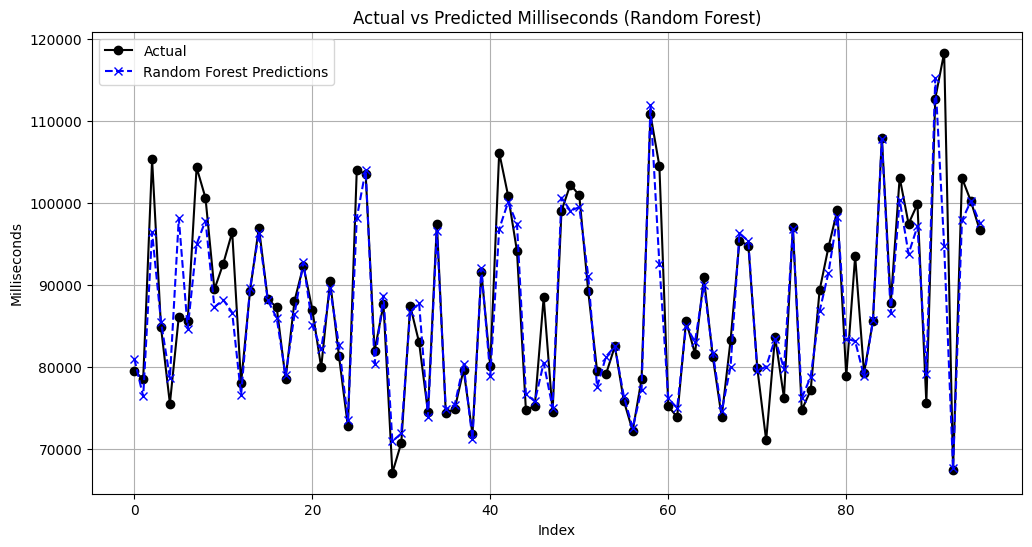

In [136]:
import matplotlib.pyplot as plt

# Plot the actual vs predicted values
plt.figure(figsize=(12, 6))
plt.plot(y_test.values, label='Actual', marker='o', linestyle='-', color='black')
plt.plot(y_pred, label='Random Forest Predictions', marker='x', linestyle='--', color='blue')

# Add labels, legend, and title
plt.xlabel('Index')
plt.ylabel('Milliseconds')
plt.title('Actual vs Predicted Milliseconds (Random Forest)')
plt.legend()
plt.grid(True)
plt.show()

# SOY UN PUTO GENIOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOO

bUENO en realidad no xd pero la idea ha estao guapa

### Ahora la regresión lineal

In [138]:
# Select features and target
X = best_lap_times[['name', 'year']]
y = best_lap_times['milliseconds']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Define the preprocessing steps for the categorical and numerical features
preprocessor = ColumnTransformer(
    transformers=[
        ('name', OneHotEncoder(handle_unknown='ignore'), ['name']),
        ('year', StandardScaler(), ['year'])
    ]
)

# Create the pipeline
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression())
])

# Train the pipeline
pipeline.fit(X_train, y_train)

# Make predictions
y_pred = pipeline.predict(X_test)

# Evaluate the model
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error: {mse}")
print(f"Mean Absolute Error: {mae}")
print(f"R^2 Score: {r2}")

Mean Squared Error: 47598409.88612372
Mean Absolute Error: 4415.8698699230135
R^2 Score: 0.636175824037736


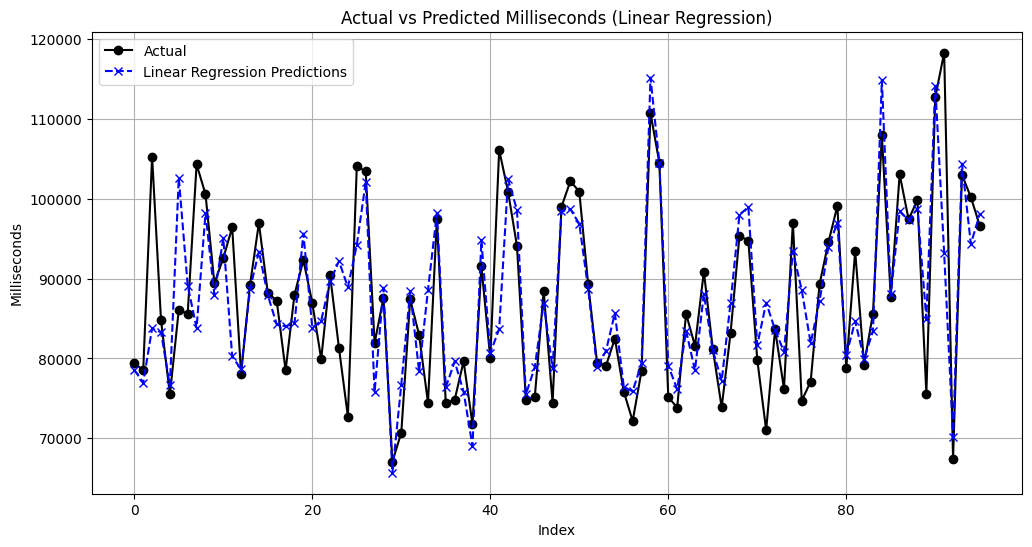

In [140]:
import matplotlib.pyplot as plt

# Plot the actual vs predicted values
plt.figure(figsize=(12, 6))
plt.plot(y_test.values, label='Actual', marker='o', linestyle='-', color='black')
plt.plot(y_pred, label='Linear Regression Predictions', marker='x', linestyle='--', color='blue')

# Add labels, legend, and title
plt.xlabel('Index')
plt.ylabel('Milliseconds')
plt.title('Actual vs Predicted Milliseconds (Linear Regression)')
plt.legend()
plt.grid(True)
plt.show()

##### Intento solo una carrera (FALLIDO)

In [119]:
# Filter the dataset for the 'Australian Grand Prix'
australian_gp = df[df['name'] == 'Australian Grand Prix']

# Group by year and find the minimum lap time for each year
best_times = australian_gp.groupby('year')['milliseconds'].min().reset_index()

# Merge the best times back with the original dataset to get additional details
best_times_details = australian_gp.merge(best_times, on=['year', 'milliseconds'], how='inner')

# Display the result
best_times_details.sort_values(by='year', inplace=True)
best_times_details.head()

,raceId,driverId,lap,position,time,milliseconds,year,name
13,224,35,27,1,1:33.421,93421,1996,Australian Grand Prix
12,207,49,36,1,1:30.585,90585,1997,Australian Grand Prix
11,191,57,39,2,1:31.649,91649,1998,Australian Grand Prix
10,175,30,55,8,1:32.112,92112,1999,Australian Grand Prix
9,158,22,41,2,1:31.481,91481,2000,Australian Grand Prix


In [120]:
best_times_details.shape

(25, 8)

Lol estoy roto no sé por qué pensé que saldrían más datos si en realidad hay 25 jodidos años

In [123]:
best_times_details[['time', 'milliseconds']].head(25)

,time,milliseconds
13,1:33.421,93421
12,1:30.585,90585
11,1:31.649,91649
10,1:32.112,92112
9,1:31.481,91481
8,1:28.214,88214
7,1:28.541,88541
6,1:27.724,87724
5,1:24.125,84125
4,1:25.683,85683
